# 01_analysis notebook¶
#### This notebook takes in the output from 00_pull_clean and does the first step of my analysis.
##### This notebook will get more complex as I continue working on this project, but for now, it is fairly simple. It includes the work I did for Milestone 1 as this Milestone was instead focused on organizing my repo and cleaning up my work. This notebook will grow and likely turn into multiple parts in the coming days.

As of 8/18, this notebook takes in the cleaned data, and produces a figure looking at unemployment in South Africa. As stated above, it will produce more shortly as this repository grows with my project. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# same logic as from previous notebook to make path reproducable
DATA = "../data/"
OUTPUT = "../output/"

## South Africa informal employment in 2010

## Load in previous notebook and compute informal and unemployment rates

In [8]:
df = pd.read_stata(DATA + "cleaned_southafrica_2010.dta")

# update df to get when employed
employed = df[df["Status_Exp"] == "Employed"]

# get to informal employment sorted by if hosting or not, then convert to rate (takes advantage of boolean 0-1 property)
informal_count = employed.groupby("host_group")["Infempl"].apply(lambda x: (x == 'Informal employment').mean() * 100)

# look at unemployment
unemployment_count = df[df["Status_Exp"].isin(["Employed", "Unemployed"])
    ].groupby("host_group")["Status_Exp"].apply(lambda x: (x == "Unemployed").mean() * 100)

print(informal_count)
print(unemployment_count)

host_group
Metro Host    25.727273
Non-Host      39.207936
Name: Infempl, dtype: float64
host_group
Metro Host    28.034020
Non-Host      40.667316
Name: Status_Exp, dtype: float64


## Create figure
#### Code below is taken from Milestone 1, with updates recommended in feedback. That code intitally used the classwork as a strong guide

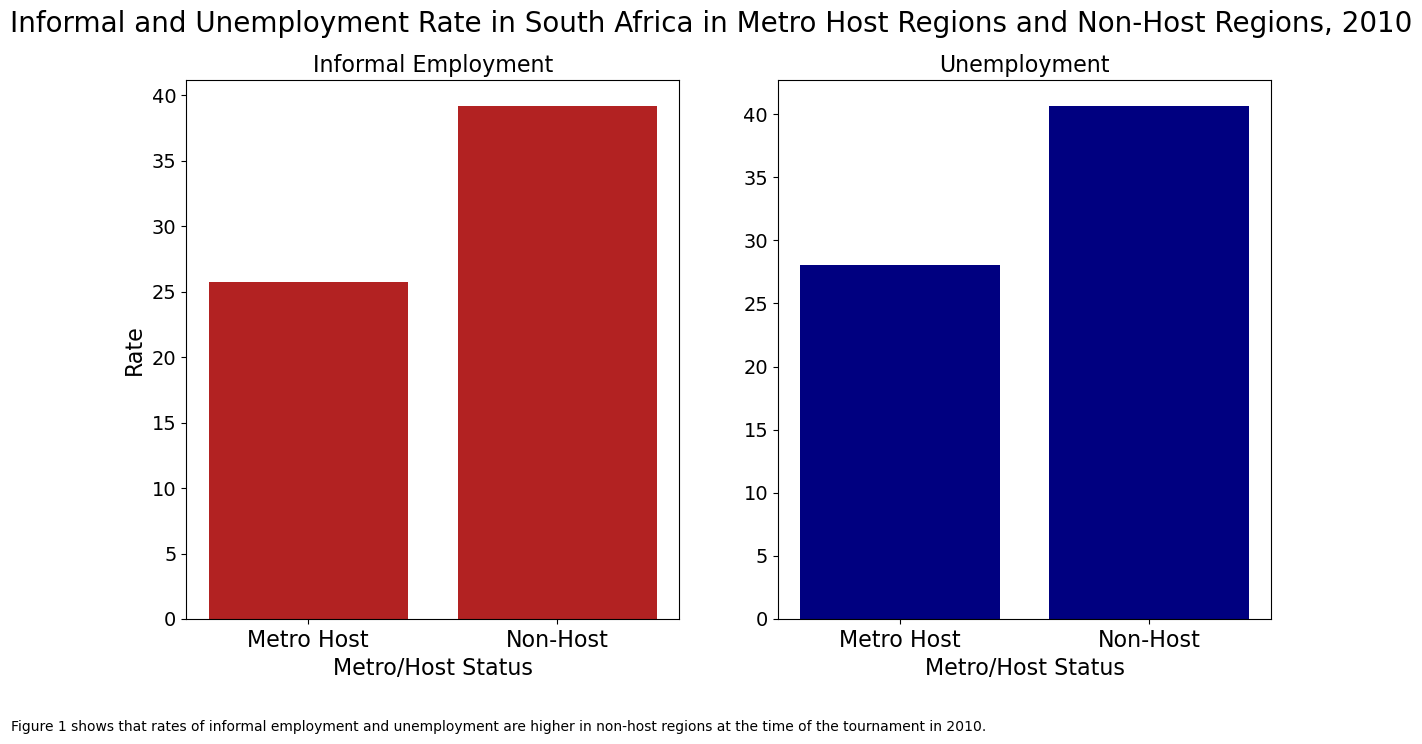

In [15]:
plt.figure(figsize=(14,7))

# left panel (informal)
plt.subplot(1, 2, 1)
plt.bar(informal_count.index, informal_count, color="firebrick")
plt.xticks(fontsize=16)
plt.yticks(fontsize=14)
plt.xlabel("Metro/Host Status", fontsize=16)
plt.ylabel("Rate", fontsize=16)
plt.title("Informal Employment", fontsize=16)

# right panel (unemployed)
plt.subplot(1, 2, 2)
plt.bar(unemployment_count.index, unemployment_count, color="navy")
plt.xticks(fontsize=16)
plt.yticks(fontsize=14)
plt.xlabel("Metro/Host Status", fontsize=16)
plt.title("Unemployment", fontsize=16)

plt.suptitle("Informal and Unemployment Rate in South Africa in Metro Host Regions and Non-Host Regions, 2010", fontsize=20)
plt.figtext(0, -0.05, "Figure 1 shows that rates of informal employment and unemployment are higher in non-host regions at the time of the tournament in 2010.")
plt.savefig(OUTPUT + "southafrica_labor2010.png", bbox_inches="tight")
plt.show()